# mmBERT-base baseline

This notebook fine-tunes [`jhu-clsp/mmBERT-base`](https://huggingface.co/jhu-clsp/mmBERT-base) for three-class German text classification.

The model distinguishes between:

- **Human-written text**
- **AI-generated text**
- **AI-assisted text**

Training uses the prepared Hugging Face dataset created for this project, with document-level train, validation, and test splits to reduce source leakage.

The notebook includes dataset preparation, tokenization, model training, probability calibration, evaluation, error analysis, length-bias analysis, and model export.

The notebook is designed to run with GPU acceleration. Required Python packages are installed in the setup cells when running in Google Colab.

## Imports

Load the core libraries used throughout the notebook for numerical processing,
dataset handling, transformer fine-tuning, and model evaluation.

In [ ]:
import numpy as np
import pandas as pd
import torch
import transformers
from pathlib import Path
from importlib.metadata import version
import json
import platform
import gc
import time
from transformers.utils import logging as transformers_logging
transformers_logging.set_verbosity_error()
from datasets import load_from_disk
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from transformers import DataCollatorWithPadding

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    EarlyStoppingCallback,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,

)

### Configuration and dataset loading

Define the main experiment settings and load the prepared three-class Hugging Face dataset from disk.

In [ ]:
MODEL_NAME = "jhu-clsp/mmBERT-base"
DATASET_PATH = "hf-dataset-3class-full"

MAX_LENGTH = 512
RANDOM_STATE = 17

dataset = load_from_disk(
    DATASET_PATH
)

dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 24986
    })
    validation: Dataset({
        features: ['id', 'file', 'text', 'label', 'language', 'split', 'source', 'source_name', 'source_type', 'document_type', 'title', 'document_id', 'target_length', 'actual_word_count', 'character_count', 'original_document_length', 'publication_date', 'date_basis', 'retrieval_date', 'license_name', 'license_url', 'source_url', 'hash', 'generator_provider', 'generator_model', 'seed_sample_id'],
        num_rows: 2906
    })
    test: Dataset({
        features: ['id', 'file', 'text', 'label', 'lan

### Tokenization

Load the mmBERT-base tokenizer, tokenize all dataset splits with a maximum sequence length of 512 tokens, and prepare dynamic padding for efficient batching.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
    )

columns_to_remove = [
    column
    for column in dataset["train"].column_names
    if column != "label"
]

tokenized_dataset = dataset.map(
    tokenize_batch,
    batched=True,
    remove_columns=columns_to_remove,
    desc="Tokenizing dataset",
)

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if torch.cuda.is_available() else None,
)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/46.4k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

Tokenizing dataset:   0%|          | 0/24986 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2906 [00:00<?, ? examples/s]

Tokenizing dataset:   0%|          | 0/2737 [00:00<?, ? examples/s]

### Model initialization

Load the pretrained mmBERT-base checkpoint with a three-class classification head and determine the mixed-precision format supported by the available GPU.

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={
        0: "HUMAN",
        1: "AI",
        2: "AI_ASSISTED",
    },
    label2id={
        "HUMAN": 0,
        "AI": 1,
        "AI_ASSISTED": 2,
    },
)

use_bf16 = (
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)

print("BF16:", use_bf16)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.23GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

BF16: True


### Training configuration

Define the optimization settings, evaluation strategy, mixed-precision behavior, and accuracy metric used during fine-tuning.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1,
    )

    return {
        "accuracy": accuracy_score(
            labels,
            predictions,
        )
    }


training_args = TrainingArguments(
    output_dir="checkpoints-mmbert-base",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,
    warmup_steps=235,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=100,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=2,

    bf16=use_bf16,
    fp16=torch.cuda.is_available() and not use_bf16,

    report_to="none",

    seed=RANDOM_STATE,
    data_seed=RANDOM_STATE,
)

### Trainer

Create the Hugging Face Trainer using the tokenized training and validation sets, dynamic padding, accuracy evaluation, and early stopping.

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ],
)

In [ ]:
train_result = trainer.train()

{'loss': '1.064', 'grad_norm': '28.34', 'learning_rate': '8.426e-06', 'epoch': '0.03201'}
{'loss': '0.5733', 'grad_norm': '130.8', 'learning_rate': '1.694e-05', 'epoch': '0.06402'}
{'loss': '0.5135', 'grad_norm': '28.99', 'learning_rate': '1.986e-05', 'epoch': '0.09603'}
{'loss': '0.4033', 'grad_norm': '29.07', 'learning_rate': '1.964e-05', 'epoch': '0.128'}
{'loss': '0.3565', 'grad_norm': '29.51', 'learning_rate': '1.942e-05', 'epoch': '0.1601'}
{'loss': '0.2871', 'grad_norm': '5.024', 'learning_rate': '1.92e-05', 'epoch': '0.1921'}
{'loss': '0.3089', 'grad_norm': '76.56', 'learning_rate': '1.898e-05', 'epoch': '0.2241'}
{'loss': '0.3196', 'grad_norm': '5.167', 'learning_rate': '1.877e-05', 'epoch': '0.2561'}
{'loss': '0.3376', 'grad_norm': '13.12', 'learning_rate': '1.855e-05', 'epoch': '0.2881'}
{'loss': '0.292', 'grad_norm': '34.55', 'learning_rate': '1.833e-05', 'epoch': '0.3201'}
{'loss': '0.2986', 'grad_norm': '18.01', 'learning_rate': '1.811e-05', 'epoch': '0.3521'}
{'loss': '0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.2116', 'grad_norm': '68.01', 'learning_rate': '1.351e-05', 'epoch': '1.024'}
{'loss': '0.1102', 'grad_norm': '0.007892', 'learning_rate': '1.329e-05', 'epoch': '1.056'}
{'loss': '0.1249', 'grad_norm': '0.8107', 'learning_rate': '1.307e-05', 'epoch': '1.088'}
{'loss': '0.123', 'grad_norm': '0.008', 'learning_rate': '1.286e-05', 'epoch': '1.12'}
{'loss': '0.09021', 'grad_norm': '27.66', 'learning_rate': '1.264e-05', 'epoch': '1.152'}
{'loss': '0.115', 'grad_norm': '0.00179', 'learning_rate': '1.242e-05', 'epoch': '1.184'}
{'loss': '0.1227', 'grad_norm': '0.01762', 'learning_rate': '1.22e-05', 'epoch': '1.216'}
{'loss': '0.174', 'grad_norm': '0.02271', 'learning_rate': '1.198e-05', 'epoch': '1.248'}
{'loss': '0.1227', 'grad_norm': '0.004246', 'learning_rate': '1.176e-05', 'epoch': '1.28'}
{'loss': '0.09873', 'grad_norm': '0.0298', 'learning_rate': '1.154e-05', 'epoch': '1.312'}
{'loss': '0.1165', 'grad_norm': '3.183', 'learning_rate': '1.132e-05', 'epoch': '1.344'}
{'loss': '0

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.07841', 'grad_norm': '0.3316', 'learning_rate': '6.726e-06', 'epoch': '2.017'}
{'loss': '0.05774', 'grad_norm': '0.002089', 'learning_rate': '6.508e-06', 'epoch': '2.049'}
{'loss': '0.02395', 'grad_norm': '0.001788', 'learning_rate': '6.289e-06', 'epoch': '2.081'}
{'loss': '0.03341', 'grad_norm': '29.14', 'learning_rate': '6.07e-06', 'epoch': '2.113'}
{'loss': '0.03368', 'grad_norm': '0.001253', 'learning_rate': '5.851e-06', 'epoch': '2.145'}
{'loss': '0.02894', 'grad_norm': '0.002165', 'learning_rate': '5.632e-06', 'epoch': '2.177'}
{'loss': '0.0174', 'grad_norm': '24', 'learning_rate': '5.413e-06', 'epoch': '2.209'}
{'loss': '0.02036', 'grad_norm': '3.546', 'learning_rate': '5.194e-06', 'epoch': '2.241'}
{'loss': '0.002175', 'grad_norm': '0.006244', 'learning_rate': '4.975e-06', 'epoch': '2.273'}
{'loss': '0.03571', 'grad_norm': '0.0001967', 'learning_rate': '4.756e-06', 'epoch': '2.305'}
{'loss': '0.0147', 'grad_norm': '0.003721', 'learning_rate': '4.538e-06', 'epoch': '

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '877.6', 'train_samples_per_second': '85.41', 'train_steps_per_second': '10.68', 'train_loss': '0.1466', 'epoch': '3'}


### Probability calibration

Use the validation split to learn a temperature-scaling parameter for mmBERT-base. Temperature scaling adjusts the confidence of the model's predicted probabilities without changing the predicted class labels.

In [ ]:
validation_output = trainer.predict(
    tokenized_dataset["validation"]
)

validation_logits = np.asarray(
    validation_output.predictions
)

y_validation = np.asarray(
    dataset["validation"]["label"],
    dtype=np.int64,
)


def fit_temperature(logits, labels):

    logits_tensor = torch.tensor(
        logits,
        dtype=torch.float64,
    )

    labels_tensor = torch.tensor(
        labels,
        dtype=torch.long,
    )

    log_temperature = torch.nn.Parameter(
        torch.zeros(
            (),
            dtype=torch.float64,
        )
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.LBFGS(
        [log_temperature],
        lr=0.1,
        max_iter=50,
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad()

        temperature = log_temperature.exp()

        loss = criterion(
            logits_tensor / temperature,
            labels_tensor,
        )

        loss.backward()

        return loss

    optimizer.step(closure)

    return float(
        log_temperature.exp().detach()
    )


def probabilities_from_logits(
    logits,
    temperature=1.0,
):

    scaled_logits = (
        np.asarray(
            logits,
            dtype=np.float64,
        )
        / temperature
    )

    scaled_logits -= scaled_logits.max(
        axis=1,
        keepdims=True,
    )

    exponentiated = np.exp(
        scaled_logits
    )

    return (
        exponentiated
        / exponentiated.sum(
            axis=1,
            keepdims=True,
        )
    )


MMBERT_BASE_TEMPERATURE = fit_temperature(
    validation_logits,
    y_validation,
)

print(
    f"Learned mmBERT-base temperature: "
    f"{MMBERT_BASE_TEMPERATURE:.4f}"
)

Learned mmBERT-base temperature: 3.1116


### Calibration evaluation

Compare mmBERT-base's probability quality before and after temperature scaling. The Brier score and log loss measure how well the predicted probabilities match the true class labels, with lower values indicating better calibration.

In [ ]:
from sklearn.metrics import log_loss
import numpy as np
import pandas as pd


def multiclass_brier_score(y_true, probabilities, n_classes=3):

    y_onehot = np.eye(n_classes)[y_true]

    return np.mean(
        np.sum(
            (probabilities - y_onehot) ** 2,
            axis=1,
        )
    )


uncalibrated_validation_probabilities = probabilities_from_logits(
    validation_logits
)

calibrated_validation_probabilities = probabilities_from_logits(
    validation_logits,
    MMBERT_BASE_TEMPERATURE,
)


calibration_comparison = pd.DataFrame(
    [
        {
            "model": "Uncalibrated",

            "Brier score": multiclass_brier_score(
                y_validation,
                uncalibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                uncalibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },

        {
            "model": "Temperature-scaled",

            "Brier score": multiclass_brier_score(
                y_validation,
                calibrated_validation_probabilities,
            ),

            "Log loss": log_loss(
                y_validation,
                calibrated_validation_probabilities,
                labels=[0, 1, 2],
            ),
        },
    ]
).set_index("model")


calibration_comparison.style.format(
    "{:.4f}"
)

,Brier score,Log loss
model,,
Uncalibrated,0.0637,0.2438
Temperature-scaled,0.0550,0.1079


### Final split evaluation

Evaluate the calibrated mmBERT-base model on the training, validation, and test splits using accuracy, multiclass Brier score, log loss, and confusion matrices.

In [ ]:
split_logits = {
    "validation": validation_logits
}

for split_name in ("train", "test"):
    prediction_output = trainer.predict(
        tokenized_dataset[split_name]
    )

    split_logits[split_name] = np.asarray(
        prediction_output.predictions
    )


def evaluate_split(split_name):
    y_true = np.asarray(
        dataset[split_name]["label"],
        dtype=np.int64,
    )

    probabilities = probabilities_from_logits(
        split_logits[split_name],
        MMBERT_BASE_TEMPERATURE,
    )

    y_pred = np.argmax(
        probabilities,
        axis=1,
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    return {
        "split": split_name,

        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "brier_score": multiclass_brier_score(
            y_true,
            probabilities,
        ),

        "log_loss": log_loss(
            y_true,
            probabilities,
            labels=[0, 1, 2],
        ),

        "confusion_matrix": cm,
    }


evaluation = pd.DataFrame(
    [
        evaluate_split("train"),
        evaluate_split("validation"),
        evaluate_split("test"),
    ]
).set_index("split")


evaluation.style.format(
    {
        "accuracy": "{:.2%}",
        "brier_score": "{:.4f}",
        "log_loss": "{:.4f}",
    }
)

,accuracy,brier_score,log_loss,confusion_matrix
split,,,,
train,99.90%,0.0029,0.0205,[[8334 0 8] [ 1 8318 5] [ 12 0 8308]]
validation,96.66%,0.0550,0.1079,[[925 0 46] [ 2 954 11] [ 32 6 930]]
test,96.64%,0.0559,0.1074,[[863 0 51] [ 0 903 9] [ 30 2 879]]


### Test-set confusion matrix

Visualize the three-class confusion matrix for mmBERT-base on the test split to inspect which classes are predicted correctly and where misclassifications occur.

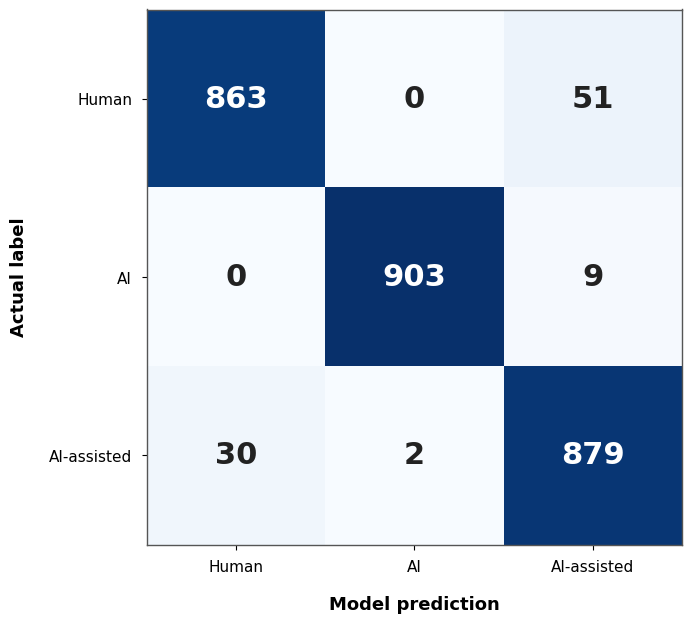

In [ ]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_BASE_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[0, 1, 2],
)

class_names = [
    "Human",
    "AI",
    "AI-assisted",
]

fig, ax = plt.subplots(figsize=(7, 7))

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(3):
    for column in range(3):

        value = test_matrix[row, column]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=22,
            fontweight="bold",
        )

ax.set_xticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_yticks(
    [0, 1, 2],
    labels=class_names,
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-base-confmat-3class.svg"
)

plt.show()

### Binary Human-vs-AI confusion matrix

Evaluate mmBERT-base only on Human and fully AI-generated test samples. AI-assisted samples are excluded, and the remaining Human and AI probabilities are renormalized before applying a binary decision threshold.

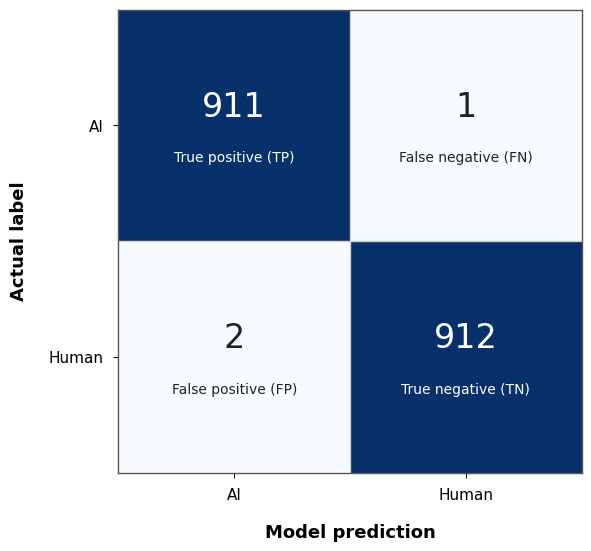

In [ ]:
y_test_all = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

mask = y_test_all != 2

y_test = y_test_all[mask]

test_logits_binary = split_logits["test"][mask]

test_probabilities = probabilities_from_logits(
    test_logits_binary,
    MMBERT_BASE_TEMPERATURE,
)

human_prob = test_probabilities[:, 0]
ai_prob = test_probabilities[:, 1]

total = human_prob + ai_prob

human_prob = human_prob / total
ai_prob = ai_prob / total

y_test_pred = (
    ai_prob >= 0.5
).astype(np.int64)

test_matrix = confusion_matrix(
    y_test,
    y_test_pred,
    labels=[1, 0],
)

cell_labels = np.asarray(
    [
        ["True positive (TP)", "False negative (FN)"],
        ["False positive (FP)", "True negative (TN)"],
    ]
)

fig, ax = plt.subplots(
    figsize=(6, 6)
)

ax.imshow(
    test_matrix,
    cmap="Blues",
    vmin=0,
    vmax=test_matrix.max(),
)

for row in range(2):
    for column in range(2):

        value = test_matrix[
            row,
            column
        ]

        text_color = (
            "white"
            if value > test_matrix.max() / 2
            else "#222222"
        )

        ax.text(
            column,
            row - 0.08,
            f"{value:,}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=24,
        )

        ax.text(
            column,
            row + 0.14,
            cell_labels[row, column],
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
        )

ax.set_xticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_yticks(
    [0, 1],
    labels=["AI", "Human"],
)

ax.set_xlabel(
    "Model prediction",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    "Actual label",
    fontsize=13,
    fontweight="bold",
    labelpad=15,
)

ax.axhline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.axvline(
    0.5,
    color="#d0d0d0",
    linewidth=1,
)

ax.tick_params(
    axis="both",
    labelsize=11,
    pad=7,
)

for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1)

fig.tight_layout()

plt.savefig(
    "mmbert-base-confmat-human-ai.svg"
)

plt.show()

### Error analysis

Inspect mmBERT-base's highest-confidence misclassifications on the test set, including the true label, predicted class, calibrated class probabilities, source information, generator metadata, and a short text preview.

In [ ]:
label_names = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

test_probabilities = probabilities_from_logits(
    split_logits["test"],
    MMBERT_BASE_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

prediction_confidence = np.max(
    test_probabilities,
    axis=1,
)

test_errors = pd.DataFrame(
    {
        "id": dataset["test"]["id"],
        "actual": [
            label_names[label]
            for label in y_test
        ],
        "prediction": [
            label_names[label]
            for label in y_test_pred
        ],
        "prediction_confidence": prediction_confidence,
        "human_probability": test_probabilities[:, 0],
        "ai_probability": test_probabilities[:, 1],
        "ai_assisted_probability": test_probabilities[:, 2],
        "source_name": dataset["test"]["source_name"],
        "generator_model": dataset["test"]["generator_model"],
        "text": [
            text[:300]
            for text in dataset["test"]["text"]
        ],
    }
)

test_errors = test_errors[
    test_errors["actual"]
    != test_errors["prediction"]
].copy()

test_errors.sort_values(
    "prediction_confidence",
    ascending=False,
).head(20).style.format(
    {
        "prediction_confidence": "{:.2%}",
        "human_probability": "{:.2%}",
        "ai_probability": "{:.2%}",
        "ai_assisted_probability": "{:.2%}",
    }
)

,id,actual,prediction,prediction_confidence,human_probability,ai_probability,ai_assisted_probability,source_name,generator_model,text
1855,20857,AI-assisted,AI,99.03%,0.34%,99.03%,0.63%,peDOCS (DIPF),gpt-5.6-luna,"Die Verteilungen der meisten imputierten Variablen stimmen weitgehend mit den beobachteten Werten überein. Eine Ausnahme bildet die Verteilung des Kriteriums: In den vollständigen Datensätzen beträgt die Studienabbruchquote 25,6 Prozent und liegt damit in einer ähnlichen Größenordnung wie die in and"
642,7368,Human,AI-assisted,98.92%,1.04%,0.04%,98.92%,peDOCS (DIPF),None,"Sadaf etwa kann sich die Verweigerung des Schulleiters der Hauptschule, ihr den Wechsel auf das Gymnasium zu ermöglichen, nur dadurch erklären, dass er seine ‚guten‘ Schüler*innen nicht abgeben will: „Ja, (.) der wollte das nicht, weil wir gute Schüler sind. Aber das habe ich nicht verstanden, weil"
201,2455,Human,AI-assisted,98.42%,1.44%,0.14%,98.42%,SSOAR,None,"Es lässt sich durch die Interpretation nicht sagen, ob es sich bei der Rückbetrachtung auf das eigene Handeln um wahre oder falsche Erinnerungen handelt, und ob die Darstellung des eigenen Handelns eins zu eins übermittelt wird. Harald Welzer merkt dazu an, dass „Zeitzeugeninterviews nicht als Quell"
189,2335,Human,AI-assisted,98.39%,1.46%,0.16%,98.39%,SSOAR,None,"Aus dieser Perspektive wird Beratung zum einen als „Entwicklungsmoment sozialen Wandels“, zum anderen als „Hilfe zur individuellen Biografie- und Identitätsgestaltung“ (Dewe/ Schwarz 2013: 13) sichtbar. Ungeachtet dieser begrifflichen Präzisierung ist jedoch die Frage weiterhin virulent, welche Funk"
1299,14661,AI,AI-assisted,98.23%,0.65%,1.11%,98.23%,Refubium (FU Berlin),gemini,Die auffallend umfangreiche Aufnahme dieser Vita in das „Buch der Lieder“ lässt sich insbesondere durch zwei Eigenschaften erklären: ihre hohe erzählerische Attraktivität („tellability“) sowie das enge Zusammenspiel satirischer Zuspitzung und moralischer Reflexion. Beide Aspekte werden im weiteren V
465,5057,Human,AI-assisted,98.14%,1.76%,0.10%,98.14%,Refubium (FU Berlin),None,"In seiner Begriffsgeschichte des Wortes „Ghetto“ spannt Jürgen Heyde einen großen historischen Bogen von den namensgebenden jüdischen Vierteln in italienischen Städten im 16. Jahrhundert über die in (Ost-)Mitteleuropa geführten innerjüdischen Emanzipationsdiskurse, die sich um den Begriff des Ghetto"
0,46,Human,AI-assisted,97.83%,2.02%,0.15%,97.83%,Refubium (FU Berlin),None,"Auf diese Weise erhalten entsprechende symbolische Grenzziehungen doch eine subtile Bedeutung. Der vorliegende Beitrag knüpft an die Forschungsliteratur zu europäischer Sozialintegration im Kontext der EU-Osterweiterung an (1) und bedient sich des Konzepts „symbolischer Grenzziehungen“ (2), um die A"
1578,17899,AI,AI-assisted,97.82%,0.73%,1.46%,97.82%,peDOCS (DIPF),gpt-6-luna,"Schulische Akteure können die praktische Ausbildung auf mehreren Ebenen mitgestalten: durch Beiträge zur Konzeption des Praxis-Curriculums und durch Unterstützung der Praxisanleitenden bei der Ausarbeitung des Ausbildungsplans. Eine koordinierte Curriculumentwicklung, an der Theorie und Praxis gemei"
72,887,Human,AI-assisted,97.26%,2.56%,0.18%,97.26%,SSOAR,None,"SK: Die wichtigste Arbeitsgrundlage der TG bildet das von Rolf Fechner erstellte und im Jahr 1992 veröffentlichte Werkverzeichnis. Fechner hat darin bibliografische Nachweise für – dem Anspruch nach – alle Veröffentlichungen von Tönnies zusammengetragen, darunter auch anonym oder unter Verwendung ei"
790,8735,Human,AI-assisted,97.19%,2.26%,0.55%,97.19%,SSOAR,None,"Man täte Michels jedoch Unrecht, wenn man ihm unterstellte, dass er die um die Jahrhundertwende aufblühende deutsche Frauenbewegung und deren Zeitschriften lediglich für seine materiellen Interessen instrumentalisierte. Er vertrat geschlechteregalitäre Positionen aus Überzeugung und warb für diese i"


### Model export

Save the fine-tuned mmBERT-base model and tokenizer together with the calibration parameter, label mapping, validation performance, training configuration, and software versions required to reproduce inference.

In [ ]:
ARTIFACT_DIR = Path("artifacts") / "mmbert-base-3class"

ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

trainer.save_model(
    ARTIFACT_DIR
)

tokenizer.save_pretrained(
    ARTIFACT_DIR
)

validation_predictions = np.argmax(
    validation_logits,
    axis=1,
)

best_validation_accuracy = accuracy_score(
    y_validation,
    validation_predictions,
)

metadata = {
    "dataset": DATASET_PATH,
    "base_model": MODEL_NAME,
    "label_mapping": {
        "human": 0,
        "ai": 1,
        "ai_assisted": 2,
    },
    "max_length": MAX_LENGTH,
    "calibration": "temperature scaling",
    "temperature": float(
        MMBERT_BASE_TEMPERATURE
    ),
    "best_validation_accuracy": float(
        best_validation_accuracy
    ),
    "best_checkpoint": (
        trainer.state.best_model_checkpoint
    ),
    "random_state": RANDOM_STATE,
    "python_version": platform.python_version(),
    "package_versions": {
        package: version(package)
        for package in [
            "datasets",
            "numpy",
            "scikit-learn",
            "torch",
            "transformers",
        ]
    },
}

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

METADATA_PATH.write_text(
    json.dumps(
        metadata,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print(
    f"Saved model and tokenizer to: "
    f"{ARTIFACT_DIR}"
)

print(
    f"Saved detector configuration to: "
    f"{METADATA_PATH}"
)

print(
    f"Validation accuracy: "
    f"{best_validation_accuracy:.2%}"
)

print(
    f"Temperature: "
    f"{MMBERT_BASE_TEMPERATURE:.4f}"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model and tokenizer to: artifacts/mmbert-base-3class
Saved detector configuration to: artifacts/mmbert-base-3class/detector-config.json
Validation accuracy: 96.66%
Temperature: 3.1116


### Reload and test the exported model

Reload the saved mmBERT-base model, tokenizer, and detector configuration from the artifact directory, move the model to the available inference device, and run a sample prediction using the stored temperature-scaling parameter.

In [ ]:
ARTIFACT_DIR = Path("artifacts") / "mmbert-base-3class"

METADATA_PATH = (
    ARTIFACT_DIR
    / "detector-config.json"
)

loaded_tokenizer = AutoTokenizer.from_pretrained(
    ARTIFACT_DIR
)

loaded_model = AutoModelForSequenceClassification.from_pretrained(
    ARTIFACT_DIR
)

loaded_config = json.loads(
    METADATA_PATH.read_text(
        encoding="utf-8"
    )
)

if torch.cuda.is_available():
    inference_device = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    inference_device = torch.device("mps")

else:
    inference_device = torch.device("cpu")

print("Device:", inference_device)

loaded_model.to(
    inference_device
)

loaded_model.eval()


def predict_probabilities(texts):
    inputs = loaded_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=loaded_config["max_length"],
        return_tensors="pt",
    )

    inputs = {
        key: value.to(inference_device)
        for key, value in inputs.items()
    }

    with torch.inference_mode():
        logits = loaded_model(
            **inputs
        ).logits

        calibrated_logits = (
            logits
            / loaded_config["temperature"]
        )

        probabilities = torch.softmax(
            calibrated_logits,
            dim=1,
        )

    return probabilities.cpu().numpy()


id2label = {
    0: "Human",
    1: "AI",
    2: "AI-assisted",
}

texts = [
    """
    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung zu messen, anstatt politische Ermessensspielräume an automatisierte Prozesse abzutreten.
    """
]

probabilities = predict_probabilities(
    texts
)

for text, probs in zip(
    texts,
    probabilities,
):
    prediction = int(
        np.argmax(probs)
    )

    label = id2label[
        prediction
    ]

    print(
        f"Prediction: {label}"
    )

    print(
        f"Human:       {probs[0]:.1%}"
    )

    print(
        f"AI:          {probs[1]:.1%}"
    )

    print(
        f"AI-assisted: {probs[2]:.1%}"
    )

    print(
        f"\n{text}"
    )

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

Device: cuda
Prediction: AI
Human:       0.0%
AI:          100.0%
AI-assisted: 0.0%


    Die fortschreitende Digitalisierung von Entscheidungsprozessen in Verwaltung und Politik wird häufig als neutraler Rationalisierungsschritt dargestellt. Diese Sichtweise verkennt jedoch den normativen Charakter technologischer Systeme. Algorithmen und datengestützte Modelle sind keine objektiv reflektierenden Instrumente; sie begründen sich stets auf spezifischen Prämissen, Datenselektionen und Zielvorgaben ihrer Entwickler. Wenn komplexe gesellschaftliche Zielkonflikte rein technokratisch behandelt werden, droht eine Entpolitisierung essenzieller Debatten. Technische Systeme können zwar Effizienz steigern und Informationsgrundlagen strukturieren, sie ersetzen jedoch weder die ethische Folgenabschätzung noch die demokratische Legitimation. Eine nachhaltige gesellschaftliche Transformation erfordert daher, die Systemarchitekturen kontinuierlich an rechtsstaatlichen Werten und sozialer Verantwortung

### Length-bias analysis

Evaluate mmBERT-base performance across different text-length ranges to check whether classification quality changes for shorter or longer samples. For each length bin, report class counts, accuracy, mean class confidence, and class-specific error rates.

In [ ]:
y_test = np.asarray(
    dataset["test"]["label"],
    dtype=np.int64,
)

texts = np.asarray(
    dataset["test"]["text"],
    dtype=object,
)

test_logits = split_logits["test"]

test_probabilities = probabilities_from_logits(
    test_logits,
    MMBERT_BASE_TEMPERATURE,
)

y_test_pred = np.argmax(
    test_probabilities,
    axis=1,
)

word_lengths = np.asarray([
    len(text.split())
    for text in texts
])

length_bins = [
    (0, 70, "≤70"),
    (71, 150, "71–150"),
    (151, 300, "151–300"),
    (301, 500, "301–500"),
    (501, 750, "501–750"),
    (751, np.inf, "750+"),
]

rows = []

for lower, upper, name in length_bins:
    bin_mask = (
        (word_lengths >= lower)
        & (word_lengths <= upper)
    )

    y_bin = y_test[bin_mask]
    pred_bin = y_test_pred[bin_mask]
    probabilities_bin = test_probabilities[
        bin_mask
    ]

    if len(y_bin) == 0:
        continue

    human_mask = y_bin == 0
    ai_mask = y_bin == 1
    ai_assisted_mask = y_bin == 2

    mean_human_score = (
        probabilities_bin[
            human_mask,
            0
        ].mean() * 100
    )

    mean_ai_score = (
        probabilities_bin[
            ai_mask,
            1
        ].mean() * 100
    )

    mean_ai_assisted_score = (
        probabilities_bin[
            ai_assisted_mask,
            2
        ].mean() * 100
    )

    human_error_rate = np.mean(
        pred_bin[human_mask] != 0
    )

    ai_error_rate = np.mean(
        pred_bin[ai_mask] != 1
    )

    ai_assisted_error_rate = np.mean(
        pred_bin[ai_assisted_mask] != 2
    )

    rows.append(
        {
            "model": "mmBERT-base",
            "length_bin": name,
            "samples": len(y_bin),
            "human_samples": human_mask.sum(),
            "ai_samples": ai_mask.sum(),
            "ai_assisted_samples": ai_assisted_mask.sum(),
            "accuracy": accuracy_score(
                y_bin,
                pred_bin,
            ),
            "mean_human_score": mean_human_score,
            "mean_ai_score": mean_ai_score,
            "mean_ai_assisted_score": mean_ai_assisted_score,
            "human_error_rate": human_error_rate,
            "ai_error_rate": ai_error_rate,
            "ai_assisted_error_rate": ai_assisted_error_rate,
        }
    )

mmbert_base_length_results_3class = pd.DataFrame(
    rows
)

mmbert_base_length_results_3class

,model,length_bin,samples,human_samples,ai_samples,ai_assisted_samples,accuracy,mean_human_score,mean_ai_score,mean_ai_assisted_score,human_error_rate,ai_error_rate,ai_assisted_error_rate
0,mmBERT-base,≤70,399,134,134,131,0.894737,82.118779,93.470102,82.957969,0.134328,0.059701,0.122137
1,mmBERT-base,71–150,293,94,122,77,0.965870,88.198943,98.823597,95.580770,0.074468,0.008197,0.025974
2,mmBERT-base,151–300,640,207,245,188,0.968750,89.669347,99.884932,95.869261,0.072464,0.000000,0.026596
3,mmBERT-base,301–500,342,106,89,147,0.994152,95.518777,99.996508,97.636679,0.000000,0.000000,0.013605
4,mmBERT-base,501–750,653,233,191,229,0.984686,93.790284,99.941755,97.074080,0.021459,0.000000,0.021834
5,mmBERT-base,750+,410,140,131,139,0.980488,92.234145,99.959620,98.119574,0.042857,0.000000,0.014388
